# Nodal Force (Eggshell) Method -- 2D EM force, three ways

Compares three electromagnetic force-computation methods on a 2D benchmark:

1. **Analytical** -- closed-form multipole series for a line current near a
   permeable cylinder (exact for linear material).
2. **Maxwell Stress Tensor (MST)** -- point-wise integration on a circle in the
   air gap.
3. **Nodal Force / Virtual Work (Eggshell)** -- central-difference of the
   magnetic co-energy under a blended virtual displacement
   (`mesh.SetDeformation`).

**Benchmark**: straight wire (I = 1000 A) at the origin, iron cylinder
(mu_r = 1000, R = 0.05 m) at distance d = 0.3 m. The force is attractive
(negative Fx).

**Key point**: `mesh.Curve(3)` is required for accurate force on curved
boundaries -- without curving, the polygon approximation of the circle loses
~2% area and causes ~9% force error.

**VERIFIED result** (this notebook, finest mesh): the nodal-force (virtual-work)
method matches the analytic Fx = -1.90096e-02 N/m to ~0.01%, and agrees with
MST to ~6e-4%. The nodal method is already accurate on the coarsest mesh
(+0.01%) where MST still has +0.28% error.

References: Coulomb (1983, virtual work in FEM); Henrotte & Hameyer (2004,
Maxwell stress vs virtual work); Henrotte, Deliege & Hameyer (2003, eggshell).

Promoted from `examples/nodal_force/` on 2026-06-26. The executed notebook
embeds the public result and convergence plot. Checked numerical evidence lives
in `validation_test/nodal_force/nodal_force_results.json`; docs do not create a
result sidecar.

## Parameters and analytical reference

In [1]:
import numpy as np
from math import pi
from ngsolve import *
from netgen.occ import *

mu0 = 4 * pi * 1e-7
mu_r = 1000.0           # Iron relative permeability
I_wire = 1000.0         # Wire current [A]
R_wire = 0.01           # Wire radius [m]
R_cyl = 0.05            # Iron cylinder radius [m]
d = 0.3                 # Distance wire-to-iron center [m]
t_egg = 0.008           # Eggshell thickness [m]
R_outer = 3.0           # Outer boundary radius [m]
J_z = I_wire / (pi * R_wire**2)  # Current density [A/m^2]

# Method 1: analytical (line current near a permeable cylinder, 2D closed form)
#   F_x = -(mu_0 I^2 alpha R^2) / (2 pi d (d^2 - R^2)),  alpha = (mu_r-1)/(mu_r+1)
alpha = (mu_r - 1) / (mu_r + 1)
F_analytical = -mu0 * I_wire**2 * alpha * R_cyl**2 / (2 * pi * d * (d**2 - R_cyl**2))
F_dipole = -mu0 * alpha * I_wire**2 * R_cyl**2 / (2 * pi * d**3)
print(f"J = {J_z:.2e} A/m^2")
print(f"F_dipole (n=1 only) = {F_dipole:.6e} N/m")
print(f"F_exact  (closed)   = {F_analytical:.6e} N/m")

J = 3.18e+06 A/m^2
F_dipole (n=1 only) = -1.848152e-02 N/m
F_exact  (closed)   = -1.900956e-02 N/m


## FEM force kernel (MST + nodal/virtual-work)

A-formulation magnetostatic solve, then both MST (circle integration) and the
nodal-force virtual-work estimate (central difference of co-energy under a
blended `SetDeformation`).

In [2]:
def compute_force_fem(maxh_iron, order=3, curve_order=3):
    """MST and nodal force for one mesh size (A-formulation, H1 order p)."""
    wp = WorkPlane()
    wire_shape = wp.MoveTo(0, 0).Circle(R_wire).Face()
    wire_shape.name = "wire"; wire_shape.maxh = R_wire / 2
    iron_shape = wp.MoveTo(d, 0).Circle(R_cyl).Face()
    iron_shape.name = "iron"; iron_shape.maxh = maxh_iron
    R_egg_outer = R_cyl + t_egg
    egg_outer_shape = wp.MoveTo(d, 0).Circle(R_egg_outer).Face()
    eggshell_shape = egg_outer_shape - iron_shape
    eggshell_shape.name = "eggshell"; eggshell_shape.maxh = maxh_iron
    outer_shape = wp.MoveTo(0, 0).Circle(R_outer).Face()
    for edge in outer_shape.edges:
        edge.name = "outer"
    air_shape = outer_shape - wire_shape - egg_outer_shape
    air_shape.name = "air"
    geo = Glue([wire_shape, iron_shape, eggshell_shape, air_shape])
    mesh = Mesh(OCCGeometry(geo, dim=2).GenerateMesh(maxh=R_outer / 5))

    with TaskManager():
        if curve_order > 1:
            mesh.Curve(curve_order)
        fes = H1(mesh, order=order, dirichlet="outer")
        u, v = fes.TnT()
        mu_cf = mesh.MaterialCF({"iron": mu0 * mu_r}, default=mu0)
        nu_cf = 1.0 / mu_cf
        a = BilinearForm(nu_cf * grad(u) * grad(v) * dx); a.Assemble()
        f = LinearForm(J_z * v * dx("wire")); f.Assemble()
        gf_A = GridFunction(fes)
        gf_A.vec.data = a.mat.Inverse(fes.FreeDofs(), inverse="sparsecholesky") * f.vec
        B = CF((-grad(gf_A)[1], grad(gf_A)[0]))

        # Method 2: Maxwell Stress Tensor on a circle in the eggshell (air)
        R_mst = R_cyl + t_egg / 2
        n_quad = 360
        theta = np.linspace(0, 2 * pi, n_quad + 1)[:-1]
        dtheta = 2 * pi / n_quad
        Fx_MST = 0.0
        for k in range(n_quad):
            x_q = d + R_mst * np.cos(theta[k]); y_q = R_mst * np.sin(theta[k])
            nx = np.cos(theta[k]); ny = np.sin(theta[k])
            mip = mesh(x_q, y_q)
            Bx_val = B[0](mip); By_val = B[1](mip)
            Bn = Bx_val * nx + By_val * ny
            B2 = Bx_val**2 + By_val**2
            Fx_MST += (1.0 / mu0) * (Bx_val * Bn - 0.5 * B2 * nx) * R_mst * dtheta

        # Method 3: nodal force (eggshell + virtual work)
        fes_blend = H1(mesh, order=1)
        gf_blend = GridFunction(fes_blend)
        gf_blend.Set(1.0, definedon=mesh.Materials("iron"))

    fes_def = VectorH1(mesh, order=1)
    gf_def = GridFunction(fes_def)
    delta = 1e-7
    energy_density = 0.5 * nu_cf * (grad(gf_A)[0]**2 + grad(gf_A)[1]**2)

    def compute_energy():
        return Integrate(energy_density, mesh, order=2 * order + 4)

    gf_def.components[0].vec.data = delta * gf_blend.vec
    gf_def.components[1].vec[:] = 0.0
    mesh.SetDeformation(gf_def); W_plus = compute_energy(); mesh.UnsetDeformation()
    gf_def.components[0].vec.data = (-delta) * gf_blend.vec
    gf_def.components[1].vec[:] = 0.0
    mesh.SetDeformation(gf_def); W_minus = compute_energy(); mesh.UnsetDeformation()
    Fx_nodal = -(W_plus - W_minus) / (2 * delta)   # F_x = -dW/dx
    return mesh.ne, Fx_MST, Fx_nodal

## Convergence study and embedded results

In [3]:
maxh_list = [0.02, 0.012, 0.008, 0.005, 0.003]
results = []
print(f"{'maxh':>8s}  {'NE':>6s}  {'F_MST':>14s}  {'F_nodal':>14s}  "
      f"{'err_MST%':>9s}  {'err_nodal%':>11s}")
print("-" * 75)
for maxh in maxh_list:
    ne, Fx_MST, Fx_nodal = compute_force_fem(maxh, order=3, curve_order=3)
    err_MST = (Fx_MST - F_analytical) / abs(F_analytical) * 100
    err_nodal = (Fx_nodal - F_analytical) / abs(F_analytical) * 100
    results.append((maxh, ne, Fx_MST, Fx_nodal, err_MST, err_nodal))
    print(f"{maxh:8.4f}  {ne:6d}  {Fx_MST:14.6e}  {Fx_nodal:14.6e}  "
          f"{err_MST:+9.2f}  {err_nodal:+11.2f}")

mst_nodal_diff = abs(results[-1][2] - results[-1][3]) / abs(F_analytical) * 100
print(f"\nAnalytical (exact): F_x = {F_analytical:.6e} N/m")
print(f"MST vs Nodal difference (finest): {mst_nodal_diff:.4f}%")


    maxh      NE           F_MST         F_nodal   err_MST%   err_nodal%
---------------------------------------------------------------------------
  0.0200     685   -1.895599e-02   -1.900859e-02      +0.28        +0.01


  0.0120     913   -1.900563e-02   -1.900882e-02      +0.02        +0.00
  0.0080    1187   -1.900880e-02   -1.900814e-02      +0.00        +0.01


  0.0050    2005   -1.900840e-02   -1.900853e-02      +0.01        +0.01


  0.0030    4171   -1.900806e-02   -1.900793e-02      +0.01        +0.01

Analytical (exact): F_x = -1.900956e-02 N/m
MST vs Nodal difference (finest): 0.0007%


## Convergence plot

Left: Fx vs element count (both methods approach the analytic dashed line).
Right: relative error (log-log) -- the nodal/virtual-work method is accurate
even on coarse meshes, while MST converges from a larger coarse-mesh error.

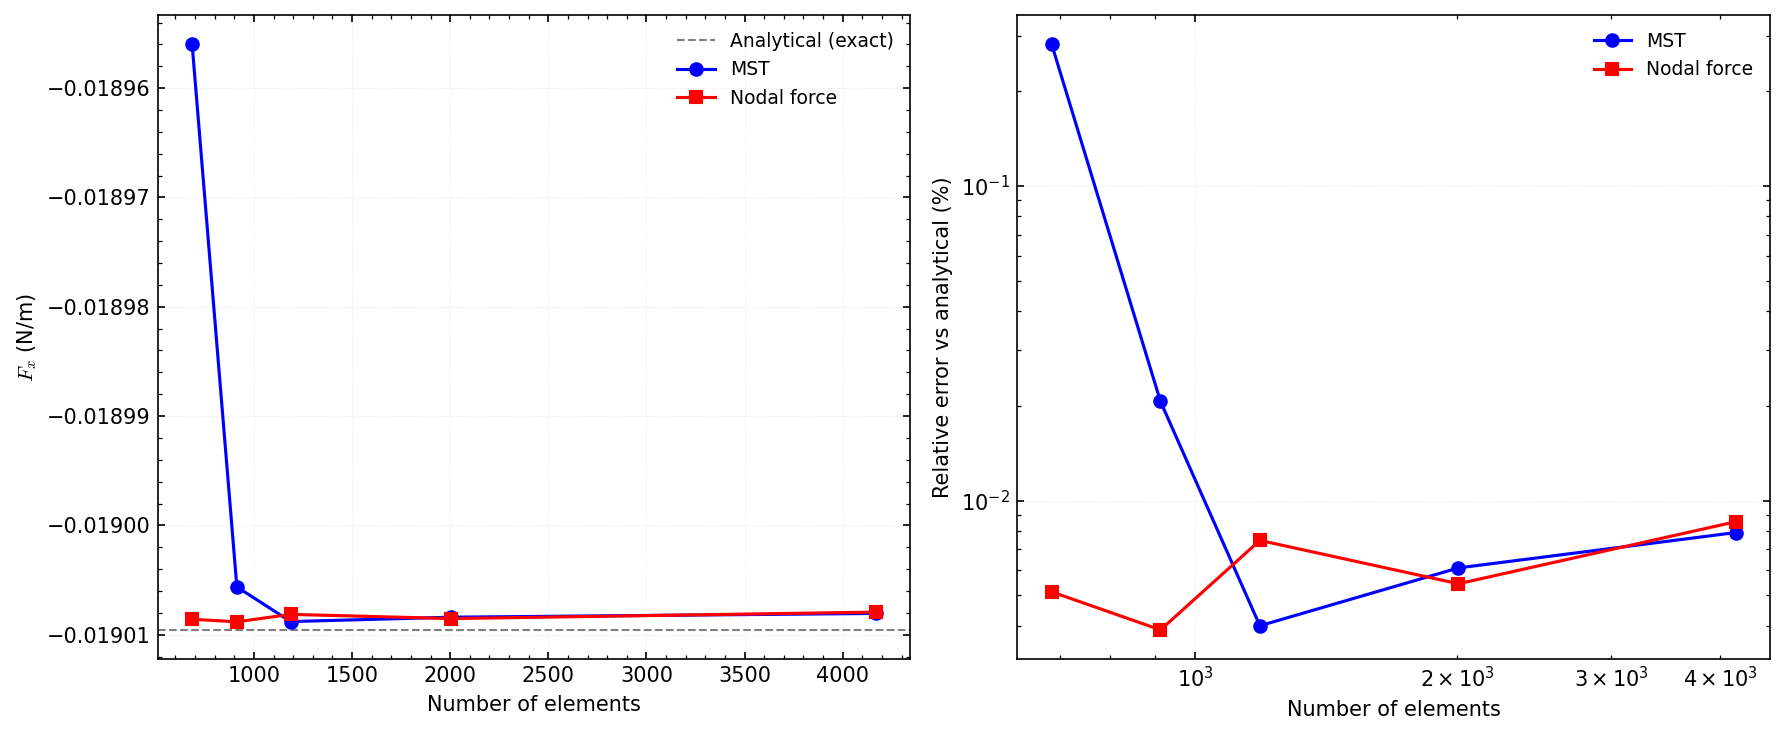

In [4]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc('mathtext', **{'rm': 'serif', 'it': 'serif:italic',
                             'bf': 'serif:bold', 'fontset': 'cm'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
ne_arr = [r[1] for r in results]
err_MST_arr = [abs(r[4]) for r in results]
err_nodal_arr = [abs(r[5]) for r in results]
F_MST_arr = [r[2] for r in results]
F_nodal_arr = [r[3] for r in results]

ax1.axhline(y=F_analytical, color='gray', linestyle='--', linewidth=1,
            label='Analytical (exact)')
ax1.plot(ne_arr, F_MST_arr, 'bo-', linewidth=1.5, markersize=6, label='MST')
ax1.plot(ne_arr, F_nodal_arr, 'rs-', linewidth=1.5, markersize=6, label='Nodal force')
ax1.set_xlabel('Number of elements'); ax1.set_ylabel('$F_x$ (N/m)')
ax1.legend(fontsize=9, frameon=False); ax1.minorticks_on()
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.grid(axis='both', which='major', c='gainsboro', linestyle=':', linewidth=0.3)

ax2.loglog(ne_arr, err_MST_arr, 'bo-', linewidth=1.5, markersize=6, label='MST')
ax2.loglog(ne_arr, err_nodal_arr, 'rs-', linewidth=1.5, markersize=6, label='Nodal force')
ax2.set_xlabel('Number of elements'); ax2.set_ylabel('Relative error vs analytical (%)')
ax2.legend(fontsize=9, frameon=False); ax2.minorticks_on()
ax2.tick_params(which='both', direction='in', top=True, right=True)
ax2.grid(axis='both', which='major', c='gainsboro', linestyle=':', linewidth=0.3)

plt.tight_layout()
plt.savefig("nodal_force_convergence.png", dpi=150, bbox_inches='tight')
plt.show()